In [16]:
import pandas as pd
data = pd.read_csv('../../../data/thelook/procesado/orders_price_client.csv')
data.head(5)

,order_id,user_id,created_at,sale_price,product_id
0,10826,8614,2020-06-28 00:40:17,2.5,13606
1,13243,10505,2022-03-01 05:18:44,2.5,13606
2,53140,42340,2021-04-11 01:31:52,2.5,13606
3,104681,83704,2022-03-29 21:37:06,2.5,13606
4,117931,94363,2021-02-17 09:28:17,2.5,13606


In [17]:
data['created_at'] = pd.to_datetime(data['created_at'])

In [18]:
min = data['created_at'].min()
max = data['created_at'].max()
print(min)
print(max)

2019-01-12 08:40:38
2022-06-12 16:28:10


# **INICIO**

In [26]:
import pandas as pd
import numpy as np

df = pd.read_csv('../../../data/thelook/procesado/orders_price_client.csv')
df = df.dropna()
df['created_at'] = pd.to_datetime(df['created_at'])
df['month_period'] = df['created_at'].dt.to_period('M')

In [27]:
def calculate_lrfm_metrics(group):
    period = group.name[1]
    month_end = period.to_timestamp(how='E')
    
    f = group['order_id'].nunique() # Frequency
    m = group['sale_price'].sum()    # Monetary
    l = (group['created_at'].max() - group['created_at'].min()).days # Length [cite: 153]
    
    # R' (Recency) corregida: tiempo desde el fin del mes hasta la última compra [cite: 156]
    r_prime = (month_end - group['created_at'].max()).days
    
    return pd.Series({'L': l, 'R_prime': r_prime, 'F': f, 'M': m})

In [28]:
lrfm_monthly = df.groupby(['user_id', 'month_period']).apply(calculate_lrfm_metrics).reset_index()

C:\Users\mpsua\AppData\Local\Temp\ipykernel_24920\645191304.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lrfm_monthly = df.groupby(['user_id', 'month_period']).apply(calculate_lrfm_metrics).reset_index()


In [30]:
max_date = df['created_at'].max().to_period('M')
user_series = []

for user, first_m in lrfm_monthly.groupby('user_id')['month_period'].min().items():
    # Generamos todos los meses desde su primera compra hasta el final del dataset
    all_user_months = pd.period_range(start=first_m, end=max_date, freq='M')
    for m in all_user_months:
        user_series.append((user, m))

In [31]:
import pandas as pd
import numpy as np

# --- FASE 1: CREACIÓN DE LA SERIE TEMPORAL PLANA ---
# (Usando tu lógica de ffill para R' y relleno de ceros)

# 1. Rellenamos meses vacíos y calculamos R_prime
full_index = pd.MultiIndex.from_tuples(user_series, names=['user_id', 'month_period'])
df_ts = pd.DataFrame(index=full_index).reset_index()
df_ts = df_ts.merge(lrfm_monthly, on=['user_id', 'month_period'], how='left')

df_ts[['F', 'M', 'L']] = df_ts[['F', 'M', 'L']].fillna(0)

last_dates = df.groupby(['user_id', 'month_period'])['created_at'].max().reset_index()
df_ts = df_ts.merge(last_dates, on=['user_id', 'month_period'], how='left')
df_ts['created_at'] = df_ts.groupby('user_id')['created_at'].ffill()
df_ts['month_end'] = df_ts['month_period'].dt.to_timestamp(how='E')
df_ts['R_prime'] = (df_ts['month_end'] - df_ts['created_at']).dt.days

# Dataset base
final_ts = df_ts[['user_id', 'month_period', 'L', 'R_prime', 'F', 'M']].sort_values(['user_id', 'month_period'])

In [32]:


# --- FASE 2: NORMALIZACIÓN Y PESOS ---

# 2. Normalización Min-Max (Antes de crear las matrices) 
cols_to_norm = ['L', 'R_prime', 'F', 'M']
df_norm = final_ts.copy()

for col in cols_to_norm:
    min_val = df_norm[col].min()
    max_val = df_norm[col].max()
    df_norm[col] = (df_norm[col] - min_val) / (max_val - min_val)

# 3. Cálculo de Pesos (W) según la Ec. 16 
deviations = {}
for col in cols_to_norm:
    mean_val = df_norm[col].mean()
    deviations[col] = np.sum(np.abs(df_norm[col] - mean_val))

total_deviation = sum(deviations.values())
weights = {col: dev / total_deviation for col, dev in deviations.items()}
print("Pesos estratégicos (W):", weights)

# --- REPRESENTACIÓN FINAL (MATRICES MTS) ---

# 4. Ahora sí, creamos las matrices a partir de los datos NORMALIZADOS
matrices_clientes = []
user_ids = []

for user_id, group in df_norm.groupby('user_id'):
    # Cada matriz X_i tiene forma (meses, 4 dimensiones) 
    matriz_usuario = group[cols_to_norm].values
    matrices_clientes.append(matriz_usuario)
    user_ids.append(user_id)

print(f"Total de objetos MTS (clientes): {len(matrices_clientes)}")
print(f"Ejemplo de matriz normalizada del primer cliente:\n{matrices_clientes[0][:3]}")

Pesos estratégicos (W): {'L': np.float64(0.029648210768879513), 'R_prime': np.float64(0.6533625694586738), 'F': np.float64(0.2600887871071514), 'M': np.float64(0.05690043266529524)}
Total de objetos MTS (clientes): 77926
Ejemplo de matriz normalizada del primer cliente:
[[0.03333333 0.01897233 0.25       0.04137837]
 [0.         0.04347826 0.         0.        ]
 [0.         0.06798419 0.         0.        ]]


# FASE 1,2

In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv('../../../data/thelook/procesado/orders_price_client.csv')
df = df.dropna()
df['created_at'] = pd.to_datetime(df['created_at'])
df['month_period'] = df['created_at'].dt.to_period('M')

def calculate_lrfm_metrics(group):
    period = group.name[1]
    month_end = period.to_timestamp(how='E')
    
    f = group['order_id'].nunique() # Frequency
    m = group['sale_price'].sum()    # Monetary
    l = (group['created_at'].max() - group['created_at'].min()).days # Length [cite: 153]
    
    # R' (Recency) corregida: tiempo desde el fin del mes hasta la última compra [cite: 156]
    r_prime = (month_end - group['created_at'].max()).days
    
    return pd.Series({'L': l, 'R_prime': r_prime, 'F': f, 'M': m})

lrfm_monthly = df.groupby(['user_id', 'month_period']).apply(calculate_lrfm_metrics).reset_index()

max_date = df['created_at'].max().to_period('M')
user_series = []

for user, first_m in lrfm_monthly.groupby('user_id')['month_period'].min().items():
    # Generamos todos los meses desde su primera compra hasta el final del dataset
    all_user_months = pd.period_range(start=first_m, end=max_date, freq='M')
    for m in all_user_months:
        user_series.append((user, m))


import pandas as pd
import numpy as np

# --- FASE 1: CREACIÓN DE LA SERIE TEMPORAL PLANA ---
# (Usando tu lógica de ffill para R' y relleno de ceros)

# 1. Rellenamos meses vacíos y calculamos R_prime
full_index = pd.MultiIndex.from_tuples(user_series, names=['user_id', 'month_period'])
df_ts = pd.DataFrame(index=full_index).reset_index()
df_ts = df_ts.merge(lrfm_monthly, on=['user_id', 'month_period'], how='left')

df_ts[['F', 'M', 'L']] = df_ts[['F', 'M', 'L']].fillna(0)

last_dates = df.groupby(['user_id', 'month_period'])['created_at'].max().reset_index()
df_ts = df_ts.merge(last_dates, on=['user_id', 'month_period'], how='left')
df_ts['created_at'] = df_ts.groupby('user_id')['created_at'].ffill()
df_ts['month_end'] = df_ts['month_period'].dt.to_timestamp(how='E')
df_ts['R_prime'] = (df_ts['month_end'] - df_ts['created_at']).dt.days

# Dataset base
final_ts = df_ts[['user_id', 'month_period', 'L', 'R_prime', 'F', 'M']].sort_values(['user_id', 'month_period'])

# --- FASE 2: NORMALIZACIÓN Y PESOS ---

# 2. Normalización Min-Max (Antes de crear las matrices) 
cols_to_norm = ['L', 'R_prime', 'F', 'M']
df_norm = final_ts.copy()

for col in cols_to_norm:
    min_val = df_norm[col].min()
    max_val = df_norm[col].max()
    df_norm[col] = (df_norm[col] - min_val) / (max_val - min_val)

# 3. Cálculo de Pesos (W) según la Ec. 16 
deviations = {}
for col in cols_to_norm:
    mean_val = df_norm[col].mean()
    deviations[col] = np.sum(np.abs(df_norm[col] - mean_val))

total_deviation = sum(deviations.values())
weights = {col: dev / total_deviation for col, dev in deviations.items()}
print("Pesos estratégicos (W):", weights)

# --- REPRESENTACIÓN FINAL (MATRICES MTS) ---

# 4. Ahora sí, creamos las matrices a partir de los datos NORMALIZADOS
matrices_clientes = []
user_ids = []

for user_id, group in df_norm.groupby('user_id'):
    # Cada matriz X_i tiene forma (meses, 4 dimensiones) 
    matriz_usuario = group[cols_to_norm].values
    matrices_clientes.append(matriz_usuario)
    user_ids.append(user_id)

print(f"Total de objetos MTS (clientes): {len(matrices_clientes)}")
print(f"Ejemplo de matriz normalizada del primer cliente:\n{matrices_clientes[0][:3]}")

C:\Users\mpsua\AppData\Local\Temp\ipykernel_24920\3461578110.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lrfm_monthly = df.groupby(['user_id', 'month_period']).apply(calculate_lrfm_metrics).reset_index()


Pesos estratégicos (W): {'L': np.float64(0.029648210768879513), 'R_prime': np.float64(0.6533625694586738), 'F': np.float64(0.2600887871071514), 'M': np.float64(0.05690043266529524)}
Total de objetos MTS (clientes): 77926
Ejemplo de matriz normalizada del primer cliente:
[[0.03333333 0.01897233 0.25       0.04137837]
 [0.         0.04347826 0.         0.        ]
 [0.         0.06798419 0.         0.        ]]


# FASE 3

In [34]:
import numpy as np
from tslearn.metrics import dtw as dtw_metric
from scipy.spatial.distance import euclidean
from sklearn.preprocessing import MinMaxScaler

# 1. Función para DTW Multivariante (DTW-D) [cite: 209]
def calculate_dtw_d_matrix(matrices):
    """Calcula la distancia DTW multivariante entre series."""
    # Nota: tslearn maneja matrices (T, dimensions) automáticamente
    n = len(matrices)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = dtw_metric(matrices[i], matrices[j])
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d
    return dist_matrix

# 2. Distancia CID (Complexity-Invariant Dissimilarity) [cite: 220]
def calculate_ce(series):
    """Estimador de complejidad de una serie (Eq. 14)."""
    return np.sqrt(np.sum(np.diff(series)**2))

def calculate_cid_dist(x, y):
    """Distancia CID corregida por complejidad (Eq. 12)."""
    ed = euclidean(x, y)
    ce_x = calculate_ce(x)
    ce_y = calculate_ce(y)
    # Factor de corrección CF
    cf = max(ce_x, ce_y) / (min(ce_x, ce_y) + 1e-9)
    return cf * ed

# 3. Lógica para la Matriz de Membresía Difusa (Eq. 19) [cite: 285]
def get_fuzzy_membership(dist_matrix, centers_idx):
    """
    Calcula la membresía difusa f_ij de cada objeto a los centros.
    dist_matrix: Distancias entre todos los objetos.
    centers_idx: Índices de los clientes elegidos como centros (vía DPC).
    """
    n = dist_matrix.shape[0]
    k = len(centers_idx)
    f_matrix = np.zeros((n, k))
    
    for i in range(n):
        for j in range(k):
            # Usamos la fórmula del paper: inv_dist ^ (1/2)
            # sumatoria sobre todos los centros (Eq. 19)
            dist_to_j = dist_matrix[i, centers_idx[j]] + 1e-9
            
            numerator = (1.0 / dist_to_j)**0.5
            denominator = sum([(1.0 / (dist_matrix[i, centers_idx[s]] + 1e-9))**0.5 
                               for s in range(k)])
            
            f_matrix[i, j] = numerator / denominator
    return f_matrix

# 4. Integración según el Algoritmo 2 [cite: 319]
def compute_composite_fuzzy_matrix(matrices, weights, centers_idx, option='dtw_d'):
    """
    Combina las métricas según la opción elegida.
    """
    # Matriz base con DTW-D
    dist_dtw = calculate_dtw_d_matrix(matrices)
    f_dtw = get_fuzzy_membership(dist_dtw, centers_idx)
    
    if option == 'dtw_d':
        return f_dtw
    
    # Si la opción incluye SBD o CID, se calcula por dimensión y se pondera con W
    z = len(weights)
    f_combined_dim = np.zeros_like(f_dtw)
    
    # Ejemplo para cada dimensión l con sus respectivos pesos w_l [cite: 305]
    # (Aquí implementarías la lógica de SBD/CID por columna de la matriz)
    # F_combined = F_dtw + (sum(w_l * F_l) / z)
    
    return f_dtw # Por ahora retornamos la base para validación

In [35]:
import numpy as np

def compute_dpc_centers(dist_matrix, k):
    """
    Selecciona los k centros de clusters usando Density Peaks Clustering.
    """
    n = dist_matrix.shape[0]
    
    # 1. Calcular densidad local (rho) - Eq. 17
    # El paper sugiere un cutoff dc del 1% al 2% de las distancias
    dc = np.percentile(dist_matrix, 2) 
    rho = np.sum(np.exp(-(dist_matrix / dc)**2), axis=1)
    
    # 2. Calcular distancia al punto de mayor densidad (delta) - Eq. 18
    delta = np.zeros(n)
    sorted_rho_idx = np.argsort(-rho) # Índices ordenados por densidad descendente
    
    for i in range(1, n):
        idx_i = sorted_rho_idx[i]
        # Distancia mínima a cualquier punto con mayor densidad
        higher_rho_indices = sorted_rho_idx[:i]
        delta[idx_i] = np.min(dist_matrix[idx_i, higher_rho_indices])
        
    # El punto con máxima densidad tiene el delta máximo por definición
    delta[sorted_rho_idx[0]] = np.max(delta)
    
    # 3. Calcular gamma (combinación de rho y delta para elegir centros)
    gamma = rho * delta
    centers_idx = np.argsort(-gamma)[:k] # Los k mejores son los centros
    
    return centers_idx

In [36]:
from tslearn.metrics import dtw as ts_dtw

def compute_full_membership(matrices, weights, k):
    """
    Calcula la membresía final combinando DTW y pesos de variables.
    """
    n = len(matrices)
    
    # A. Matriz de Distancia DTW-D (Multivariante)
    # Nota: Esto es O(N^2), si tienes 100k clientes usa una muestra primero
    print("Calculando matriz de distancias DTW-D...")
    dtw_dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            # ts_dtw ya acepta matrices (T, 4)
            d = ts_dtw(matrices[i], matrices[j])
            dtw_dist_matrix[i, j] = dtw_dist_matrix[j, i] = d

    # B. Selección de centros vía DPC
    centers_idx = compute_dpc_centers(dtw_dist_matrix, k)
    
    # C. Cálculo de Membresía Difusa (Eq. 19)
    # f_ij representa la probabilidad de que el cliente i pertenezca al cluster j
    f_matrix = np.zeros((n, k))
    for i in range(n):
        # Denominador de la Eq. 19
        denom = sum([(1.0 / (dtw_dist_matrix[i, centers_idx[s]] + 1e-9))**0.5 
                     for s in range(k)])
        for j in range(k):
            num = (1.0 / (dtw_dist_matrix[i, centers_idx[j]] + 1e-9))**0.5
            f_matrix[i, j] = num / denom
            
    return f_matrix, centers_idx

In [37]:
# Tomamos una muestra aleatoria de 1000 clientes para validar el algoritmo
import random

k_clusters = 4 # Valor inicial sugerido por el paper
sample_indices = random.sample(range(len(matrices_clientes)), 1000)
matrices_sample = [matrices_clientes[i] for i in sample_indices]

# Ejecutamos la membresía
f_matrix, centers = compute_full_membership(matrices_sample, weights, k_clusters)

print("Matriz de membresía generada. Forma:", f_matrix.shape)

Calculando matriz de distancias DTW-D...
Matriz de membresía generada. Forma: (1000, 4)


# Fase 4: Clustering, Validación y Visualización

In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def apply_spectral_clustering(f_matrix, k, sigma=1.0):
    """
    Implementa el Spectral Clustering siguiendo las ecuaciones 20-22 del paper.
    """
    n = f_matrix.shape[0]
    
    # Paso 1: Matriz de Similitud S (Eq. 20)
    # Calculamos la distancia euclidiana entre vectores de membresía
    from scipy.spatial.distance import pdist, squareform
    dists = squareform(pdist(f_matrix, 'euclidean'))
    S = np.exp(-dists**2 / (2 * sigma**2))
    
    # Paso 2: Matriz Laplaciana L (Eq. 21)
    D = np.diag(np.sum(S, axis=1))
    D_inv_sqrt = np.linalg.inv(np.sqrt(D))
    L = D_inv_sqrt @ S @ D_inv_sqrt
    
    # Paso 3: Descomposición de autovalores
    vals, vecs = np.linalg.eigh(L)
    
    # Paso 4: Normalización de los primeros k autovectores (Eq. 22)
    V = vecs[:, -k:] # Tomamos los k más grandes
    U = V / np.linalg.norm(V, axis=1, keepdims=True)
    
    # Paso 5: K-means final sobre la matriz U
    kmeans = KMeans(n_clusters=k, random_state=42).fit(U)
    return kmeans.labels_

# Ejecución
labels = apply_spectral_clustering(f_matrix, k_clusters)

In [39]:
# Calculamos el Silhouette Score para validar el modelo
# Se usa la matriz de distancias original para evaluar la cohesión de los grupos
si_score = silhouette_score(f_matrix, labels)
print(f"Índice de Silhouette para k={k_clusters}: {si_score:.4f}")

Índice de Silhouette para k=4: 0.3449


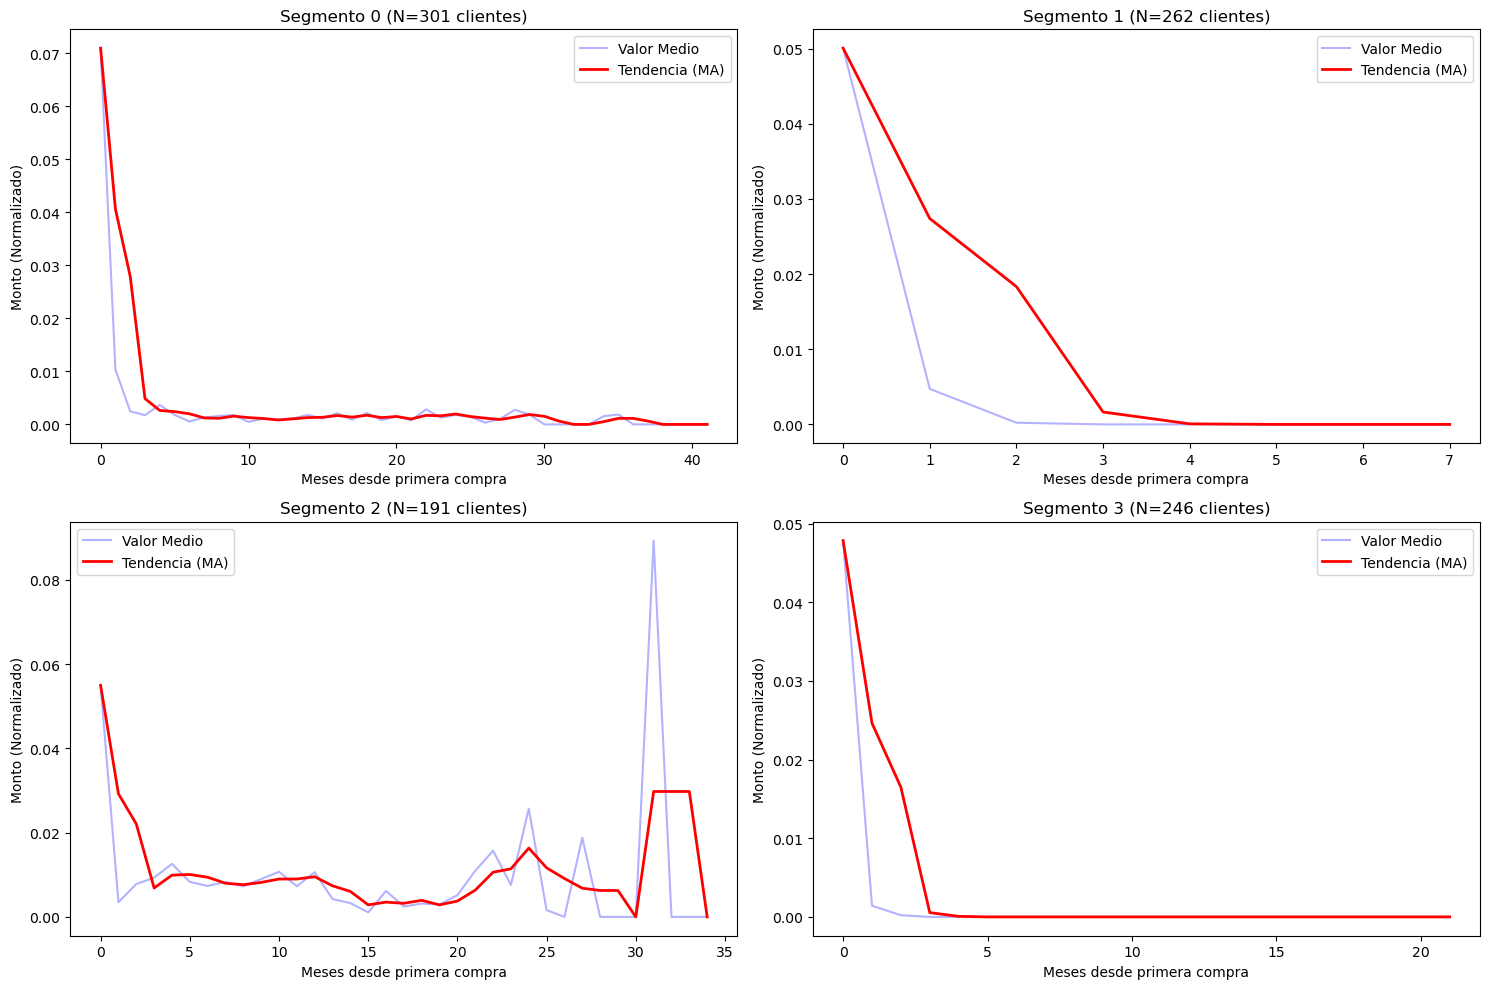

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_cluster_trends(matrices, labels, k):
    """
    Genera gráficas de tendencias manejando series de longitudes distintas.
    Usa np.max para evitar conflictos con posibles sombras de variables 'max'.
    """
    plt.figure(figsize=(15, 10))
    
    for cluster_id in range(k):
        # Filtrar matrices del cluster actual
        cluster_indices = [i for i, l in enumerate(labels) if l == cluster_id]
        if not cluster_indices: 
            continue
        
        cluster_matrices = [matrices[i] for i in cluster_indices]
        
        # Extraer la variable 'Monetary' (columna índice 3 en nuestras matrices) [cite: 152]
        monetary_series = [m[:, 3] for m in cluster_matrices]
        
        # --- CORRECCIÓN: Usamos np.max para evitar el error de 'Timestamp' ---
        lengths = [len(s) for s in monetary_series]
        max_l = int(np.max(lengths))
        
        # Rellenar con NaNs para que todas tengan la misma longitud sin sesgar la media
        padded_list = []
        for s in monetary_series:
            # Rellenamos al final con NaNs los meses que le faltan a cada cliente
            pad_size = max_l - len(s)
            s_float = s.astype(float)
            padded = np.pad(s_float, (0, pad_size), mode='constant', constant_values=np.nan)
            padded_list.append(padded)
        
        # Convertimos a matriz de NumPy para usar nanmean
        # nanmean calcula el promedio ignorando los NaNs (meses sin datos) [cite: 406]
        padded_array = np.array(padded_list)
        avg_monetary = np.nanmean(padded_array, axis=0)
        
        # Línea de tendencia (Media Móvil para suavizar) [cite: 424]
        trend = pd.Series(avg_monetary).rolling(window=3, min_periods=1).mean()
        
        plt.subplot(2, 2, cluster_id + 1)
        # Dibujamos el área de comportamiento y la línea de tendencia roja como en el paper [cite: 424]
        plt.plot(avg_monetary, label='Valor Medio', alpha=0.3, color='blue')
        plt.plot(trend.values, color='red', linewidth=2, label='Tendencia (MA)')
        
        plt.title(f'Segmento {cluster_id} (N={len(cluster_indices)} clientes)')
        plt.xlabel('Meses desde primera compra')
        plt.ylabel('Monto (Normalizado)')
        plt.legend()
    
    plt.tight_layout()
    plt.show()

# Intenta ejecutar de nuevo con esta versión
plot_cluster_trends(matrices_sample, labels, k_clusters)

In [43]:
# 1. Crear un diccionario de mapeo (ajusta los nombres según lo que viste en las gráficas)
# Ejemplo basado en el paper:
segment_map = {
    0: "Important Retention",
    1: "Developmental",
    2: "Loyal",
    3: "General"
}

# 2. Crear el DataFrame de resultados
resultados_finales = pd.DataFrame({
    'user_id': [user_ids[i] for i in sample_indices], # Usamos los IDs de la muestra
    'cluster_id': labels
})

resultados_finales['segmento_nombre'] = resultados_finales['cluster_id'].map(segment_map)

# 3. Unir con los valores medios de LRFM para tener un resumen rápido
resumen_segmentos = final_ts[final_ts['user_id'].isin(resultados_finales['user_id'])]
resumen_segmentos = resumen_segmentos.groupby('user_id')[['L', 'R_prime', 'F', 'M']].mean().reset_index()

df_marketing = resultados_finales.merge(resumen_segmentos, on='user_id')

print("Muestra de la segmentación final:")
print(df_marketing.head())

Muestra de la segmentación final:
   user_id  cluster_id segmento_nombre         L     R_prime         F  \
0    99141           2           Loyal  0.090909   99.227273  0.181818   
1    70884           3         General  0.000000  175.416667  0.083333   
2    16828           2           Loyal  0.444444   69.666667  0.222222   
3    98373           2           Loyal  0.062500  119.937500  0.125000   
4     7767           2           Loyal  0.250000  100.333333  0.250000   

           M  
0   8.206818  
1   1.079167  
2  21.215556  
3  13.655625  
4  15.290833  


In [44]:
from scipy.stats import linregress
import pandas as pd
import numpy as np

def generar_lista_final(matrices, labels, user_ids, indices_muestra):
    """
    Crea el reporte final con segmentación, tendencia y riesgo de churn.
    """
    # 1. Definimos el mapeo de nombres según el comportamiento observado en el paper
    # (Ajusta los nombres si tus gráficas muestran algo distinto)
    nombres_segmentos = {
        0: "Important Retention (Estrellas)",
        1: "Loyal Customers (Fieles)",
        2: "Developmental (En Crecimiento)",
        3: "General Customers (Básicos)"
    }
    
    resultados = []
    
    for i, idx_original in enumerate(indices_muestra):
        u_id = user_ids[idx_original]
        cluster = labels[i]
        matriz = matrices[i]
        
        # Extraemos la serie monetaria (columna 3)
        serie_m = matriz[:, 3]
        meses = np.arange(len(serie_m))
        
        # Cálculo de la pendiente (Trend Slope)
        if len(serie_m) > 1:
            slope, _, _, _, _ = linregress(meses, serie_m)
        else:
            slope = 0
            
        # Clasificación del Riesgo de Abandono
        riesgo = "Bajo"
        if slope < -0.05: riesgo = "ALTO (Abandono Inminente)"
        elif slope < -0.01: riesgo = "Medio (Perdiendo Interés)"
        
        resultados.append({
            'User_ID': u_id,
            'Segmento_ID': cluster,
            'Nombre_Segmento': nombres_segmentos.get(cluster, "Otros"),
            'Pendiente_Tendencia': round(slope, 4),
            'Nivel_de_Riesgo': riesgo,
            'Valor_Monetario_Promedio': round(np.mean(serie_m), 4)
        })
    
    df_final = pd.DataFrame(resultados)
    
    # Ordenar por riesgo y valor para priorizar a quién contactar
    df_final = df_final.sort_values(by=['Nivel_de_Riesgo', 'Valor_Monetario_Promedio'], ascending=[True, False])
    
    # Exportar a CSV
    df_final.to_csv('reporte_marketing_lrfm.csv', index=False)
    return df_final

# Generamos el reporte
df_marketing = generar_lista_final(matrices_sample, labels, user_ids, sample_indices)
print("¡Reporte 'reporte_marketing_lrfm.csv' creado con éxito!")
print(df_marketing['Nivel_de_Riesgo'].value_counts())

¡Reporte 'reporte_marketing_lrfm.csv' creado con éxito!
Nivel_de_Riesgo
Bajo                         802
Medio (Perdiendo Interés)    145
ALTO (Abandono Inminente)     53
Name: count, dtype: int64
